# Notebook 2C: Image Annotation for Swatch/Container Recognition

This notebook prepares a sample of images for annotation in Label Studio and will eventually train a classifier to distinguish lipstick image types.

**Labels (based on visual presentation of the product image):**
- `swatch` — flat color swatch with no packaging visible
- `bullet` — classic lipstick in a tube with the bullet tip visible
- `liquid` — liquid lipstick, lip stain, lacquer, or gloss — doe-foot wand or squeeze tube

These types matter for color extraction: swatch images can be clustered directly; bullet images have the color concentrated at the bullet tip (top-center crop); liquid images are harder to isolate and are likely candidates for LLM fallback.

Product metadata uses "liquid", "stain", "velvet", "lacquer" etc. in product names as a proxy signal for image type, but the true label must come from visual inspection of the image.

**Steps in this notebook:**
1. Explore product name keywords to understand the type distribution in the annotation sample
2. Copy the 222 annotation sample images to `data/img/annotation_sample/` for Label Studio
3. Launch Label Studio for annotation
4. *(future)* Load annotations and train PyTorch classifier

# Setup

In [6]:
import os
import shutil
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

BASE   = os.path.abspath('../data')
CLEAN  = os.path.join(BASE, 'img', 'original_clean')
ANNOT  = os.path.join(BASE, 'img', 'annotation_sample')
DATA   = os.path.join(BASE, 'processed')

# Exploring Product Types in the Annotation Sample

Product names in the metadata contain keywords that hint at visual format — "liquid", "stain", "velvet", etc. signal a wand/tube presentation rather than a classic bullet. This is not a ground truth label, but it gives a useful prior for understanding what annotators will encounter and helps validate the three-label schema.

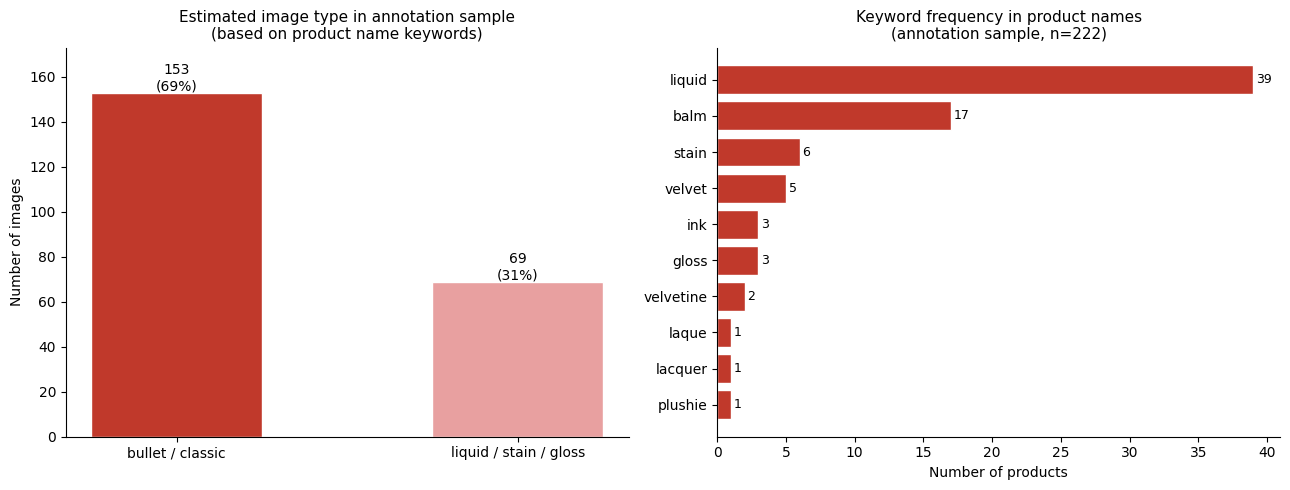


Total in sample: 222
product_type
bullet / classic          153
liquid / stain / gloss     69


In [7]:
sample   = pd.read_csv(f'{DATA}/annotation_sample.csv')
products = pd.read_csv(f'{DATA}/products_with_images.csv')
df       = sample.merge(products[['id', 'product']], on='id', how='left')

LIQUID_KEYWORDS = ['liquid', 'velvet', 'velvetine', 'plushie', 'fluid',
                   'stain', 'lacquer', 'laque', 'gloss', 'balm', 'ink', 'laquer']

def keyword_type(product_name):
    name = str(product_name).lower()
    return 'liquid / stain / gloss' if any(k in name for k in LIQUID_KEYWORDS) else 'bullet / classic'

df['product_type'] = df['product'].apply(keyword_type)

# --- figure ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Left: high-level split
counts = df['product_type'].value_counts()
colors = ['#c0392b', '#e8a0a0']
ax1.bar(counts.index, counts.values, color=colors, edgecolor='white', width=0.5)
ax1.set_title('Estimated image type in annotation sample\n(based on product name keywords)', fontsize=11)
ax1.set_ylabel('Number of images')
for i, (label, val) in enumerate(counts.items()):
    ax1.text(i, val + 1, f'{val}\n({val/len(df)*100:.0f}%)', ha='center', fontsize=10)
ax1.set_ylim(0, counts.max() + 20)
ax1.spines[['top', 'right']].set_visible(False)

# Right: individual keyword frequency
keyword_counts = {}
for kw in LIQUID_KEYWORDS:
    n = df['product'].str.lower().str.contains(kw, na=False).sum()
    if n > 0:
        keyword_counts[kw] = n

kw_series = pd.Series(keyword_counts).sort_values()
ax2.barh(kw_series.index, kw_series.values, color='#c0392b', edgecolor='white')
ax2.set_title('Keyword frequency in product names\n(annotation sample, n=222)', fontsize=11)
ax2.set_xlabel('Number of products')
for i, val in enumerate(kw_series.values):
    ax2.text(val + 0.2, i, str(val), va='center', fontsize=9)
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(f'{DATA}/../img/product_type_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nTotal in sample: {len(df)}')
print(df['product_type'].value_counts().to_string())

# Copy Annotation Sample to Label Studio Folder

The 222 images from `annotation_sample.csv` are copied from `original_clean/` (all `.jpg`) into `data/img/annotation_sample/`. Point Label Studio at this folder — it contains only the images that need to be labeled.

In [8]:
os.makedirs(ANNOT, exist_ok=True)

copied, skipped, missing = 0, 0, []

for img_name in sample.img_name:
    stem = os.path.splitext(img_name)[0]
    src  = os.path.join(CLEAN, stem + '.jpg')
    dst  = os.path.join(ANNOT, stem + '.jpg')

    if os.path.exists(dst):
        skipped += 1
        continue
    if not os.path.exists(src):
        missing.append(img_name)
        continue
    shutil.copy2(src, dst)
    copied += 1

print(f'Copied:  {copied}')
print(f'Skipped (already exists): {skipped}')
print(f'Missing from original_clean: {len(missing)}')
if missing:
    for name in missing:
        print(f'  {name}')

Copied:  208
Skipped (already exists): 0
Missing from original_clean: 14
  lipstick__bodyography__lipstick__opulent_red.jpg
  lipstick__pyt_beauty__double_duty_lipstick_gloss__deja_vu.jpg
  lipstick__kvd_beauty__everlasting_liquid_lipstick__echo.jpg
  lipstick__colourpop__ultra_blotted_lip__cypress_chill.jpg
  lipstick__becca_cosmetics__ultimate_lipstick_love__taupe.jpg
  lipstick__jcat_beauty__flash_metal_metallic_matte_lip__earthbound_explorer.jpg
  lipstick__bossy_cosmetics__bullet_lipstick__experienced.png
  lipstick__bossy_cosmetics__bullet_lipstick__graceful.jpg
  lipstick__lime_crime__matte_velvetine_lipstick__marshmallow.jpg
  lipstick__nyx_professional_makeup__dazed_diffused_blurring_lip_stick__roller_disco.jpg
  lipstick__milani__amore_satin_matte_lip_creme__violet_villain.jpg
  lipstick__lime_crime__metallic_velvetine_lipstick__eclipse.jpg
  lipstick__ulta__sheer_lipstick__red_raven.jpg
  lipstick__dose_of_colors__liquid_matte_lipstick__kiss_of_fire.jpg


14 of the 222 sampled images are missing from `original_clean/` because they were excluded by notebook 1B: 12 are transparent placeholder images (same 40KB file served by retailer pages for out-of-stock products) and 2 are corrupted files PIL cannot open. The annotation sample is therefore **208 images**. 

# Label Studio

Install and launch Label Studio. Point the image folder at `data/img/annotation_sample/` — 222 images, all `.jpg`.

**Label schema:** Classification (whole-image label) with three choices:
- `swatch` — flat color swatch, no packaging
- `bullet` — classic lipstick tube with bullet tip visible
- `liquid` — liquid lipstick, stain, lacquer, or gloss (wand or squeeze tube)

In [4]:
!pip install label-studio


You should consider upgrading via the '/Users/connie/dev/capstone_colors/.venv/bin/python3 -m pip install --upgrade pip' command.


In [ ]:
!label-studio start

=> Database and media directory: /Users/connie/Library/Application Support/label-studio
=> Static URL is set to: /static/
=> Database and media directory: /Users/connie/Library/Application Support/label-studio
=> Static URL is set to: /static/
Read environment variables from: /Users/connie/Library/Application Support/label-studio/.env
get 'SECRET_KEY' casted as '<class 'str'>' with default ''
Starting new HTTPS connection (1): pypi.org:443
https://pypi.org:443 "GET /pypi/label-studio/json HTTP/1.1" 200 36245

   ╔══════════════════════════════════════╗
   ║                                      ║
   ║   Update available 1.13.1 → 1.23.0   ║
   ║   Run pip install -U label-studio    ║
   ║                                      ║
   ╚══════════════════════════════════════╝

/Users/connie/dev/capstone_colors/.venv/lib/python3.9/site-packages/google/auth/__init__.py:54: FutureWarning: You are using a Python version 3.9 past its end of life. Google will update google-auth with critical bug fix